# P648: Alzheimer's Disease EDA & Classification

# EDA

## 1. Data Loading & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\akhsj\Downloads\alzheimers_disease_data.csv")
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


## 2. Dataset Overview

In [3]:
df.dtypes

PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
A

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [5]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [6]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates == 0:
    print("✓ No duplicates found - Data is clean!")

Duplicate rows: 0
✓ No duplicates found - Data is clean!


In [7]:
# Detect outliers for key features
key_features = ['Age', 'BMI', 'MMSE', 'ADL']

print("Outliers Detection (IQR Method):")
for feature in key_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    print(f"{feature}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

Outliers Detection (IQR Method):
Age: 0 outliers (0.0%)
BMI: 0 outliers (0.0%)
MMSE: 0 outliers (0.0%)
ADL: 0 outliers (0.0%)


## 3. Statistical Summary

In [8]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Target Variable Distribution

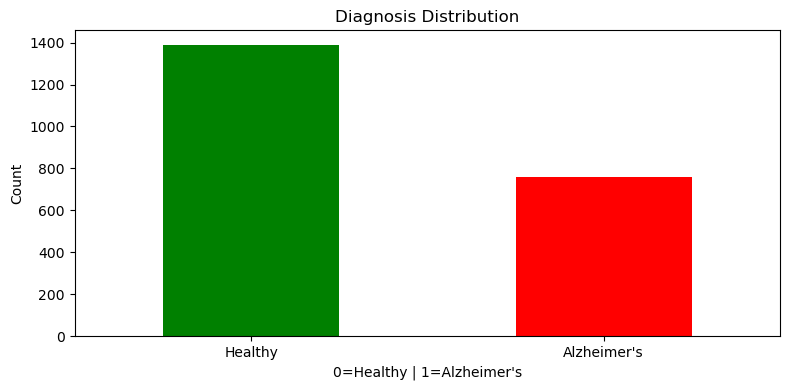

In [9]:
# Target Variable Distribution

# Healthy: 1389 (64.6%)
# Alzheimer's: 760 (35.4%)


df['Diagnosis'].value_counts()

plt.figure(figsize=(8, 4))
df['Diagnosis'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Diagnosis Distribution')
plt.xlabel('0=Healthy | 1=Alzheimer\'s')
plt.ylabel('Count')
plt.xticks([0, 1], ['Healthy', "Alzheimer's"], rotation=0)
plt.tight_layout()
plt.show()

## 5. Key Features Distribution

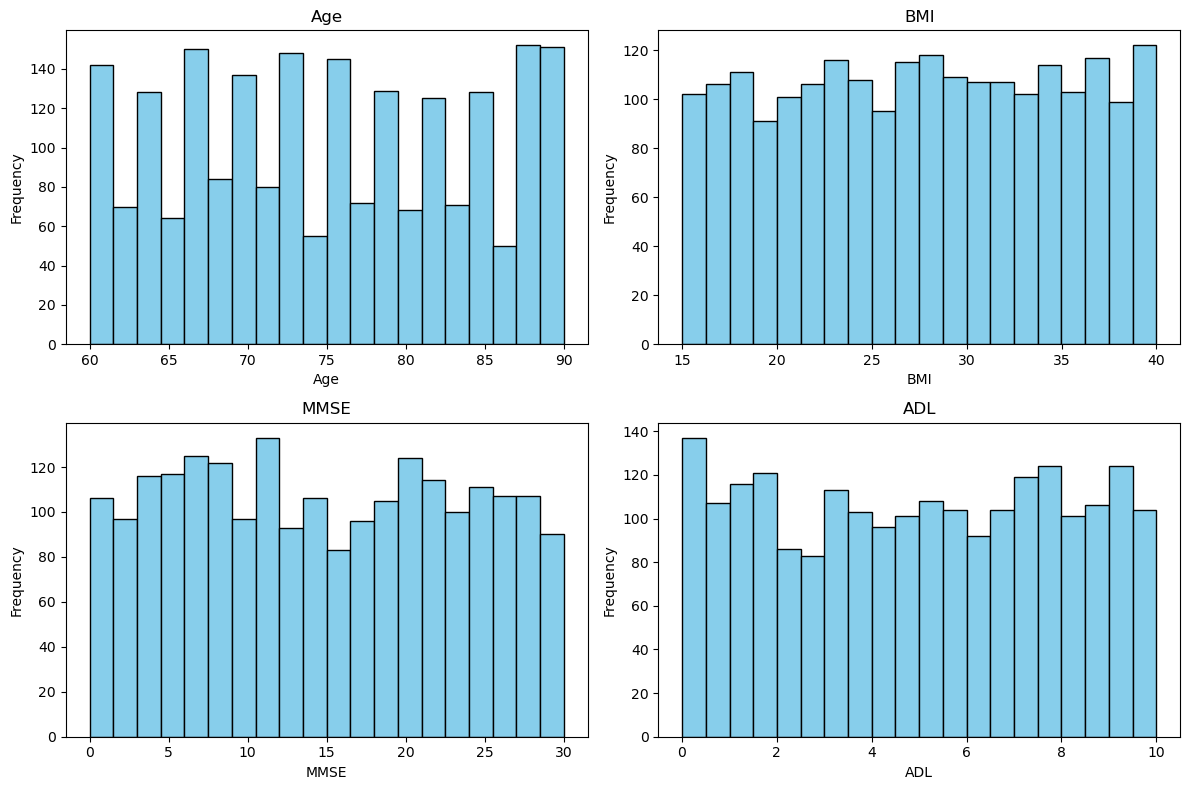

In [10]:
# Key Features Distribution

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[feature], bins=20, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'{feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Feature Relationships with Diagnosis

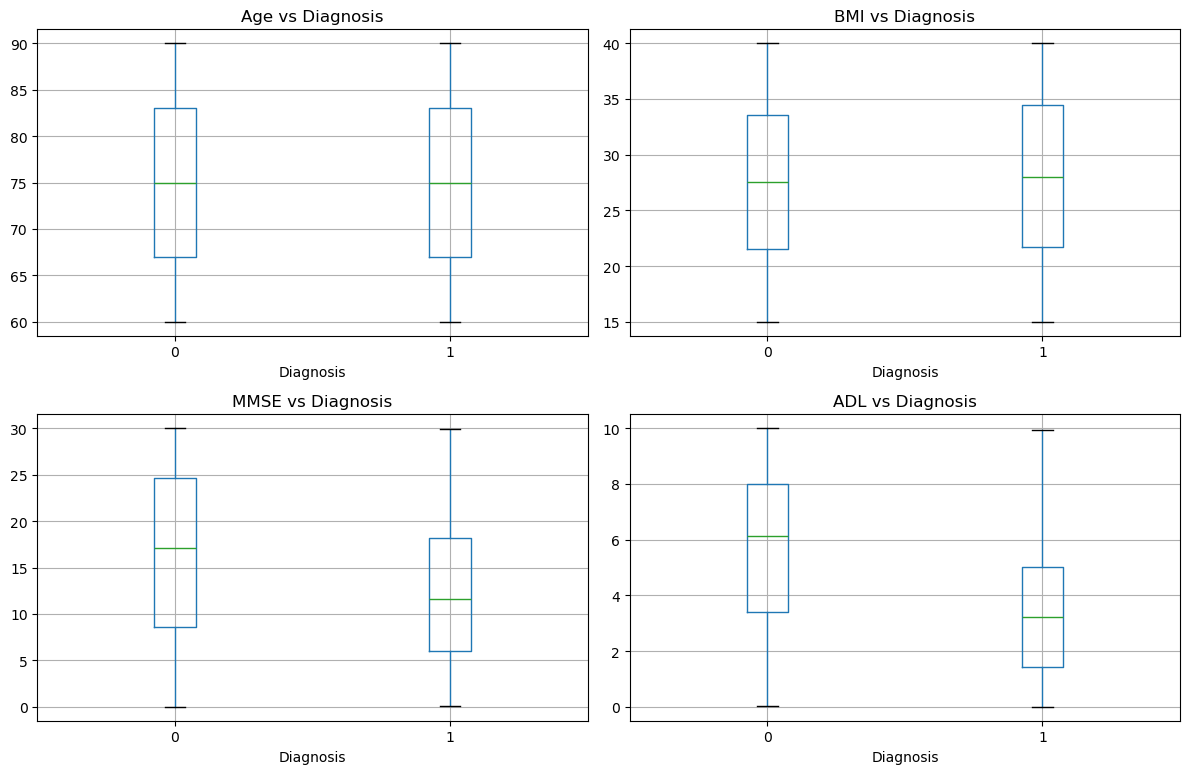

In [11]:
# Features vs Diagnosis Comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    df.boxplot(column=feature, by='Diagnosis', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs Diagnosis')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

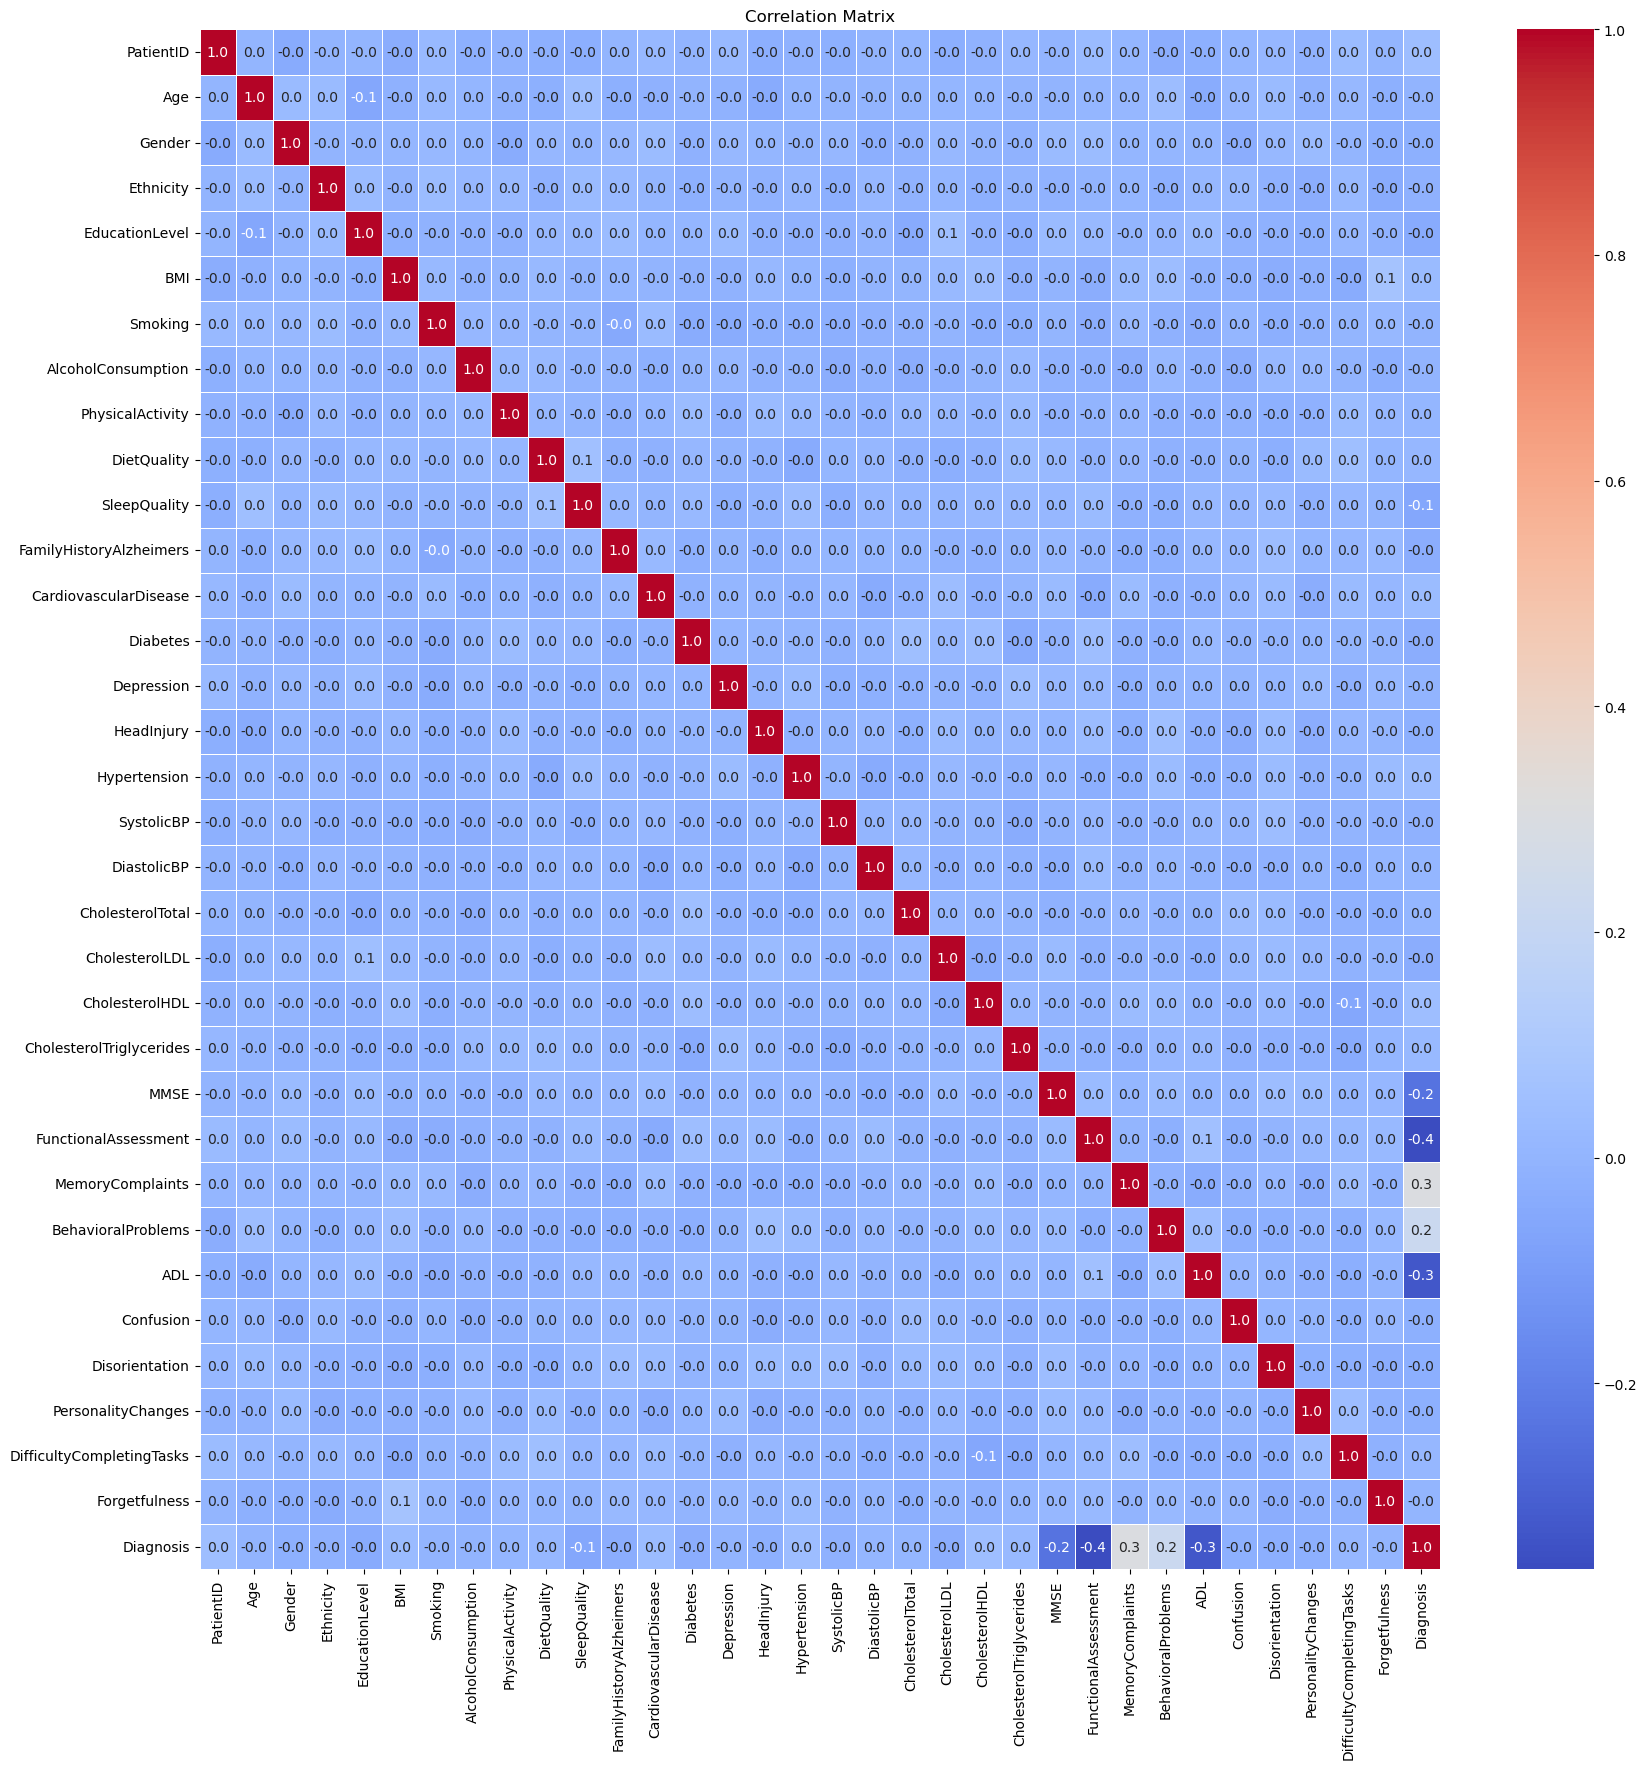

In [12]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## 8. Correlation with Diagnosis


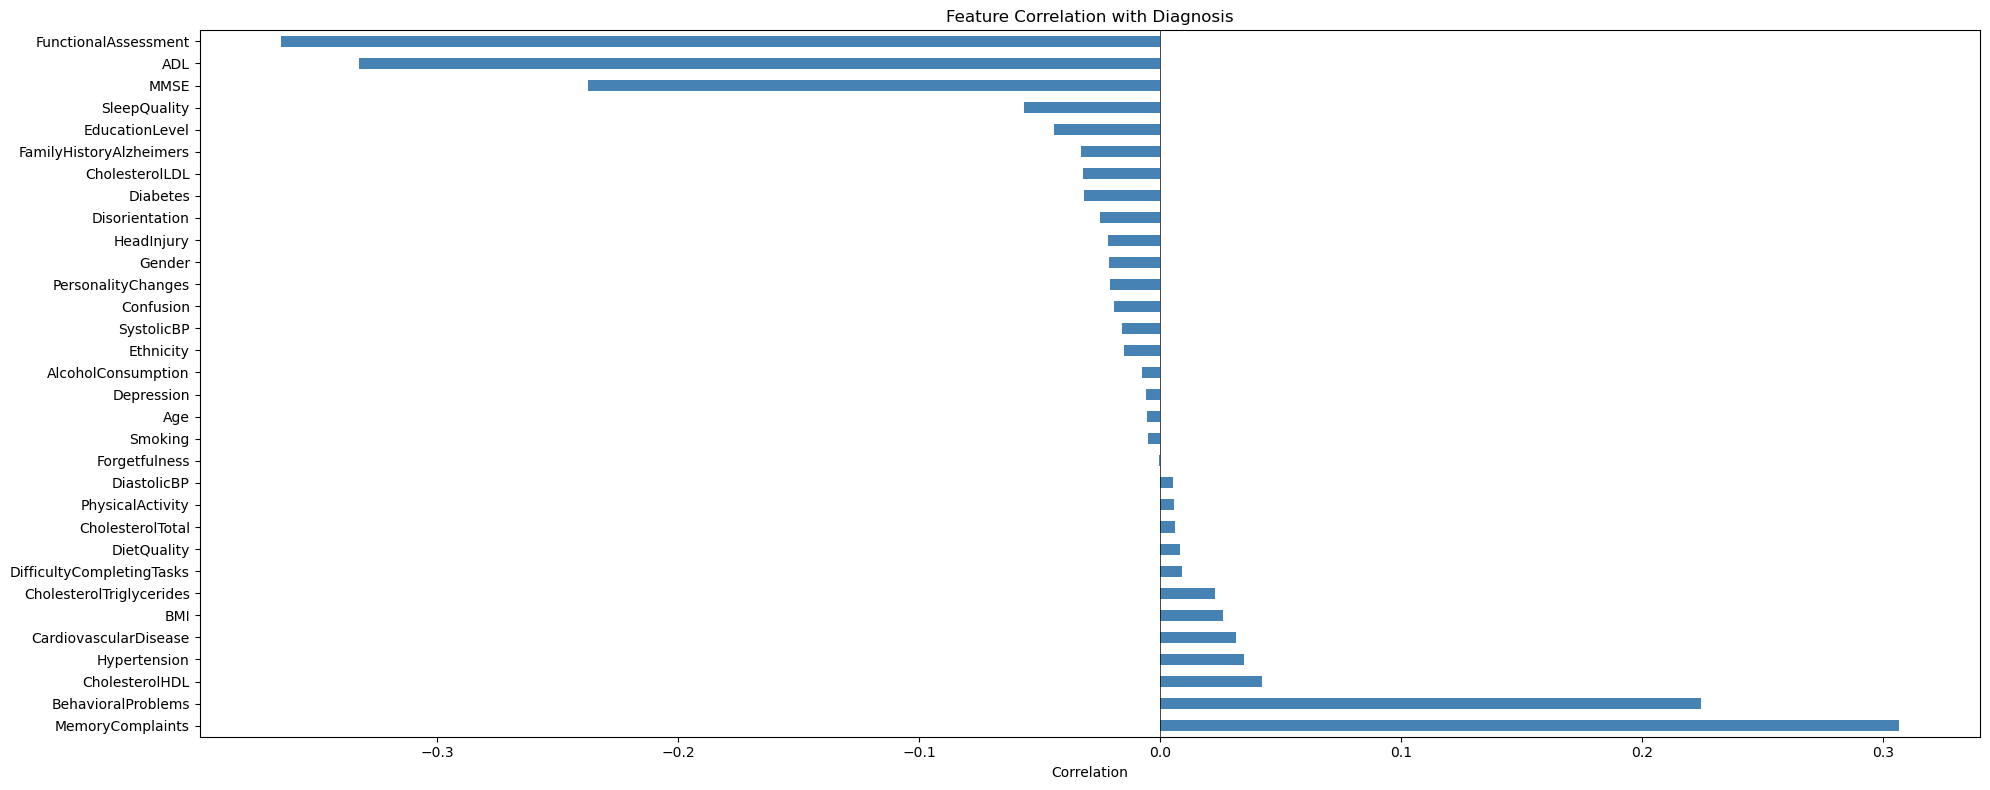

In [13]:
corr_with_diagnosis = df.corr(numeric_only=True)['Diagnosis'].sort_values(ascending=False)
corr_with_diagnosis.drop(['Diagnosis','PatientID'] ,inplace=True)

plt.figure(figsize=(20, 8))
corr_with_diagnosis[corr_with_diagnosis.index != 'Diagnosis'].plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Diagnosis')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

Top 15 Most Important Features (by correlation):
FunctionalAssessment       0.364898
ADL                        0.332346
MemoryComplaints           0.306742
MMSE                       0.237126
BehavioralProblems         0.224350
SleepQuality               0.056548
EducationLevel             0.043966
CholesterolHDL             0.042584
Hypertension               0.035080
FamilyHistoryAlzheimers    0.032900
CholesterolLDL             0.031976
Diabetes                   0.031508
CardiovascularDisease      0.031490
BMI                        0.026343
Disorientation             0.024648
Name: Diagnosis, dtype: float64


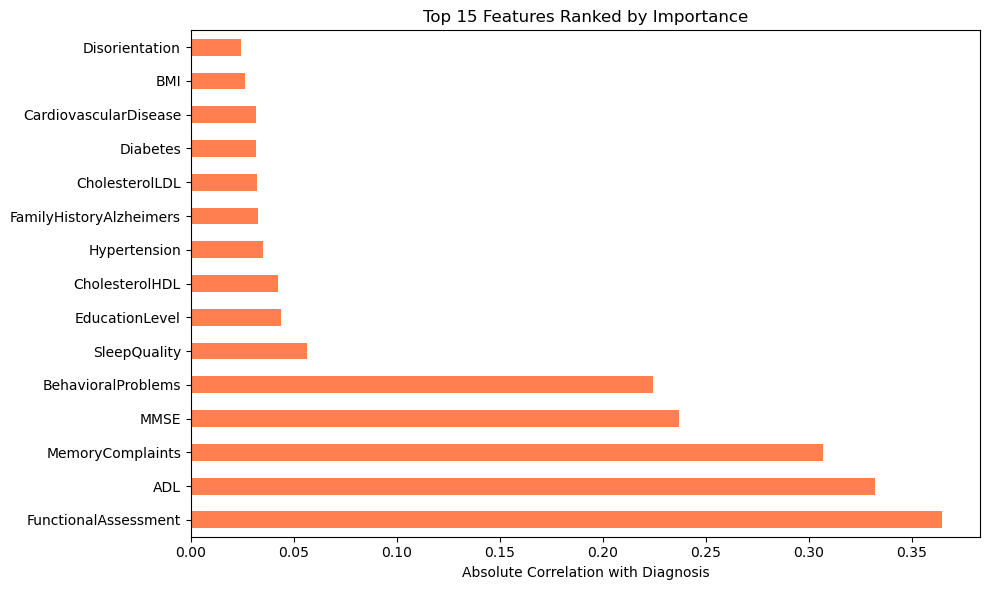

In [14]:
# Rank features by absolute correlation with diagnosis
feature_importance = corr_with_diagnosis.abs().sort_values(ascending=False)
feature_importance = feature_importance[feature_importance.index != 'Diagnosis']

print("Top 15 Most Important Features (by correlation):")
print(feature_importance.head(15))

# Visualize
plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Features Ranked by Importance')
plt.xlabel('Absolute Correlation with Diagnosis')
plt.tight_layout()
plt.show()

---

# Data Preprocessing & Preparation

## 9. Feature & Target Preparation

In [15]:
# Prepare features and target
X = df.drop(['PatientID', 'Diagnosis', 'DoctorInCharge'], axis=1)
y = df['Diagnosis']

## 10. Train-Test Split

In [16]:
# Split data into 80% train, 20% test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 11. Class Balancing with SMOTE

In [17]:
# Balance classes using SMOTE (Synthetic Minority Oversampling)  New Sample = X + rand(0,1) × (Neighbor − X) ## KNN - Neighbor
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

## 12. Feature Scaling

In [18]:
# Scale features to mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Verify preprocessing complete
print(f"Training: {X_train_scaled.shape} | Testing: {X_test_scaled.shape}")
print(f"Classes balanced: {dict(y_train_balanced.value_counts())}")

# Data ready for model training
# - X_train_scaled, y_train_balanced for training
# - X_test_scaled, y_test for evaluation

Training: (2222, 32) | Testing: (430, 32)
Classes balanced: {0: np.int64(1111), 1: np.int64(1111)}


## 13. EDA Summary & Key Insights


1. DATASET OVERVIEW:
   - Total samples: 2149
   - Total features: 35
   - Missing values: 0
   - Duplicate rows: 0

2. CLASS IMBALANCE:
   - Healthy: 1389 (64.6%)
   - Alzheimer's: 760 (35.4%)

3. TOP DISCRIMINATIVE FEATURES:
   1. FunctionalAssessment: 0.3649
   2. ADL: 0.3323
   3. MemoryComplaints: 0.3067
   4. MMSE: 0.2371
   5. BehavioralProblems: 0.2244

4. STATISTICAL SIGNIFICANCE:
...
   - Apply SMOTE to balance classes before training
   - Scale features standardization before modeling
   - Use top features for better model performance

## 13. Model Training & Evaluation


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       278
           1       0.68      0.80      0.74       152

    accuracy                           0.80       430
   macro avg       0.78      0.80      0.79       430
weighted avg       0.81      0.80      0.80       430



=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       278
           1       0.92      0.85      0.88       152

    accuracy                           0.92       430
   macro avg       0.92      0.90      0.91       430
weighted avg       0.92      0.92      0.92       430



=== Support Vector Machine Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       278
           1       0.74      0.77      0.75       152

    accuracy                   

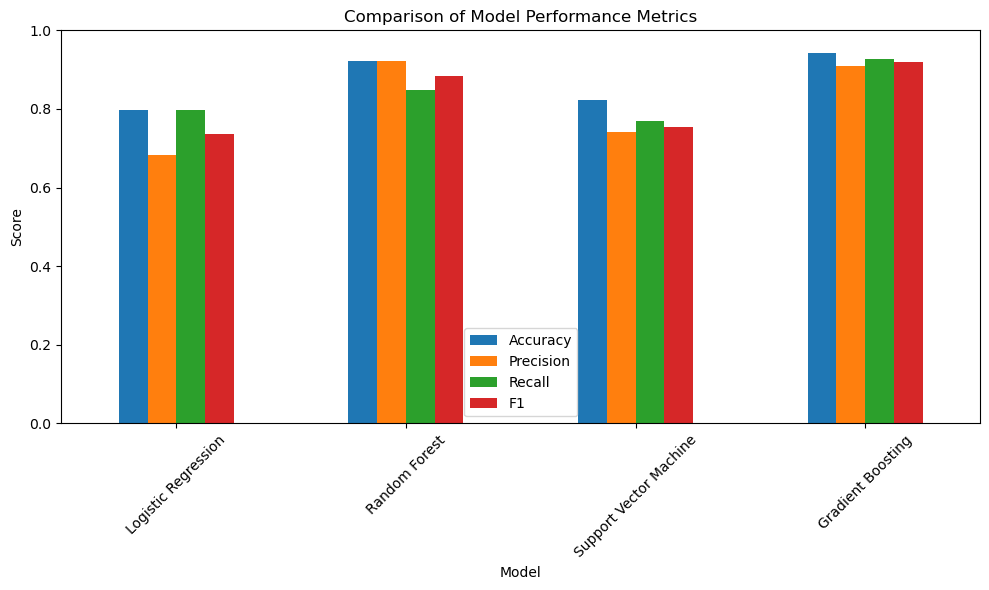

In [20]:

# %%
# -----------------------------------------------------------------------------
# 13. Model Training & Evaluation
# -----------------------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Prepare a dictionary of models to evaluate (four popular classifiers)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

# Train each model and collect evaluation metrics on the test set
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_balanced)
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

# Display results in a DataFrame
results_df = pd.DataFrame(results).set_index('Model')
results_df

# Print classification reports for deeper insight
for name, model in models.items():
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, model.predict(X_test_scaled)))
    print("\n")

# Optionally visualize performance metrics
results_df.plot(kind='bar', figsize=(10,6))
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Confusion Matrix 

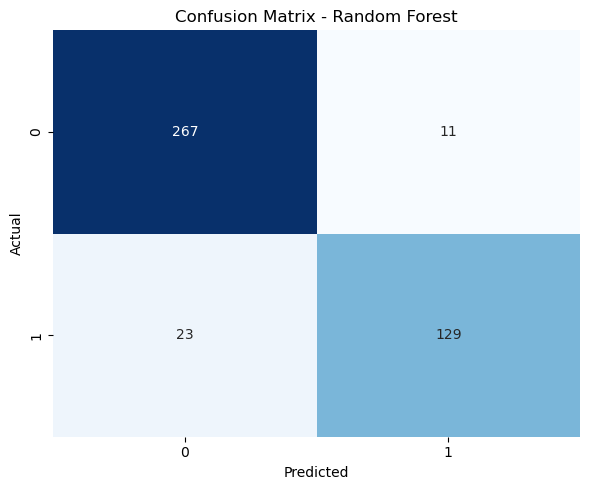

In [21]:
cm = confusion_matrix(y_test, models['Random Forest'].predict(X_test_scaled))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

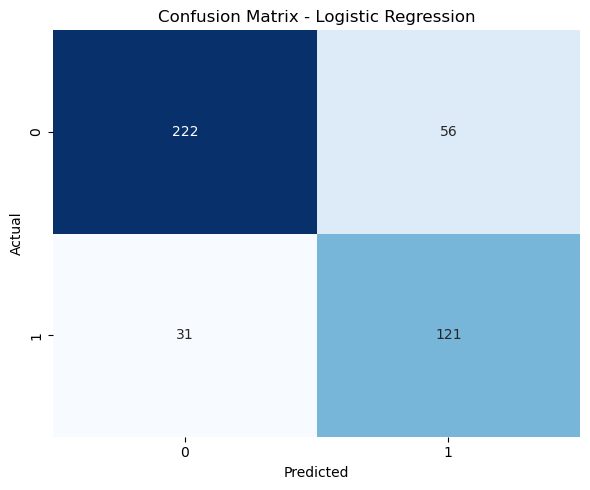

In [22]:
cm = confusion_matrix(y_test, models['Logistic Regression'].predict(X_test_scaled))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

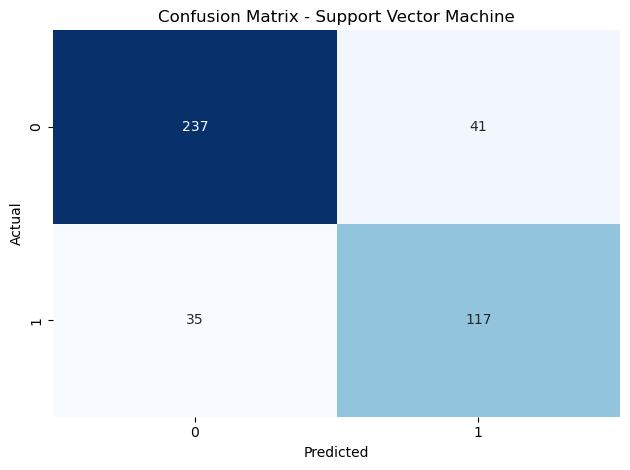

In [23]:
cm = confusion_matrix(y_test, models['Support Vector Machine'].predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

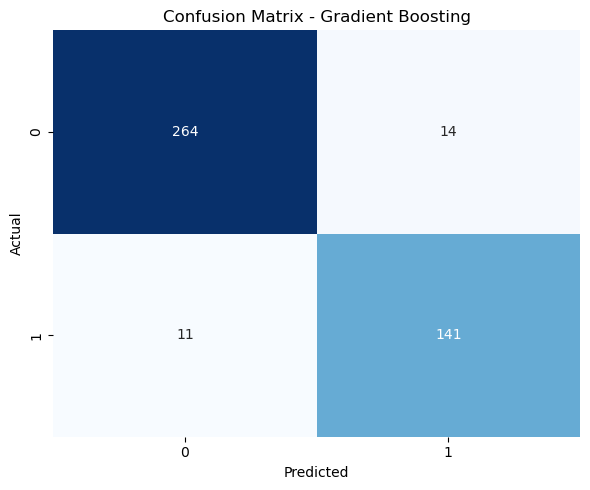

In [24]:
cm = confusion_matrix(y_test, models['Gradient Boosting'].predict(X_test_scaled))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

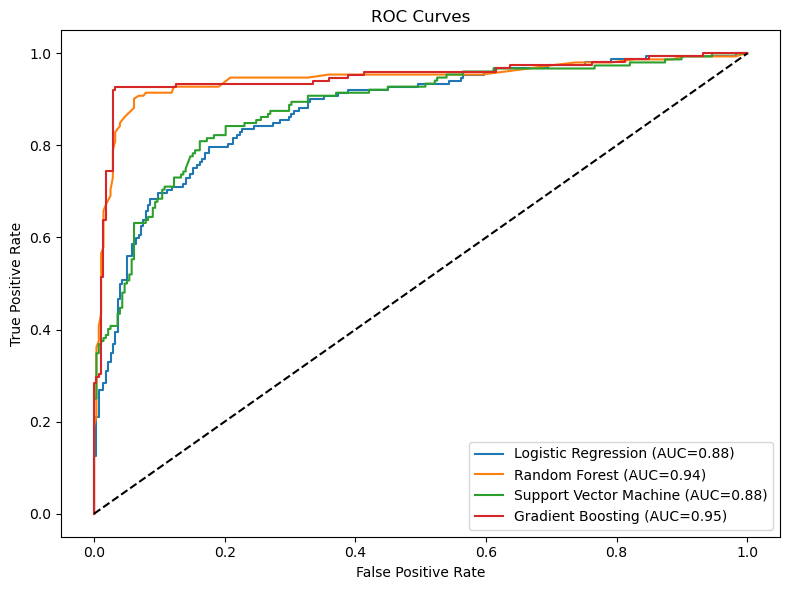

In [25]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_score = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()